# Insurance Costs Predictions

## Introduction

In this project, we will use the Individual Medical Insurance Bills dataset from Kaggle to predict medical costs based on the individual demographic and personal characteristics. The data can be found [here](https://www.kaggle.com/datasets/mirichoi0218/insurance?resource=download).

The data dictionary is displayed as follows:
- age: age of primary beneficiary
- bmi: Body mass index, providing an understanding of body, weights that are relatively high or low relative to height.
- children: Number of children covered by health insurance / Number of dependents
- smoker: Smoking
- region: the beneficiary's residential area in the US, northeast, southeast, southwest, northwest.
- charges: Individual medical costs billed by health insurance


In [115]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [116]:
insurance=pd.read_csv('C:/Users/Public/Documents/yang/Data Science Project/data/insurance.csv')

In [117]:
insurance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


- There is no missing value in the dataset.
- The predicting variable is 'charges' column,which is the medical cost

In [118]:
insurance.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [119]:
insurance.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [120]:
df=insurance.copy()

array([[<Axes: title={'center': 'charges'}>]], dtype=object)

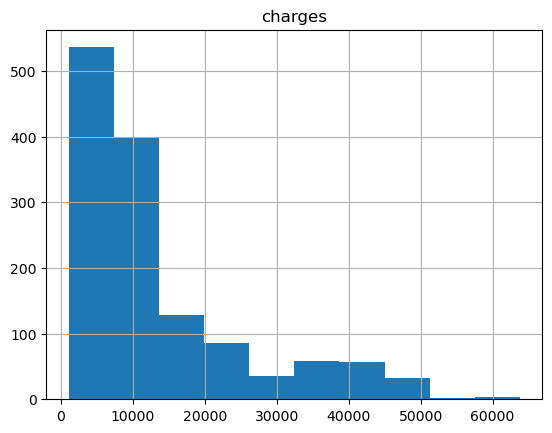

In [121]:
#plot the distribution of dependent variable "charges"
df.hist('charges')

The 'charges' is right-skewed. We could use log-transforming on the variale to minimize the effects of errors on the model.
Now, let's move on and try the original scaled dependent variable first.

First,Let's plot the categorical data to see if there are any trends among them related to "medical cost"

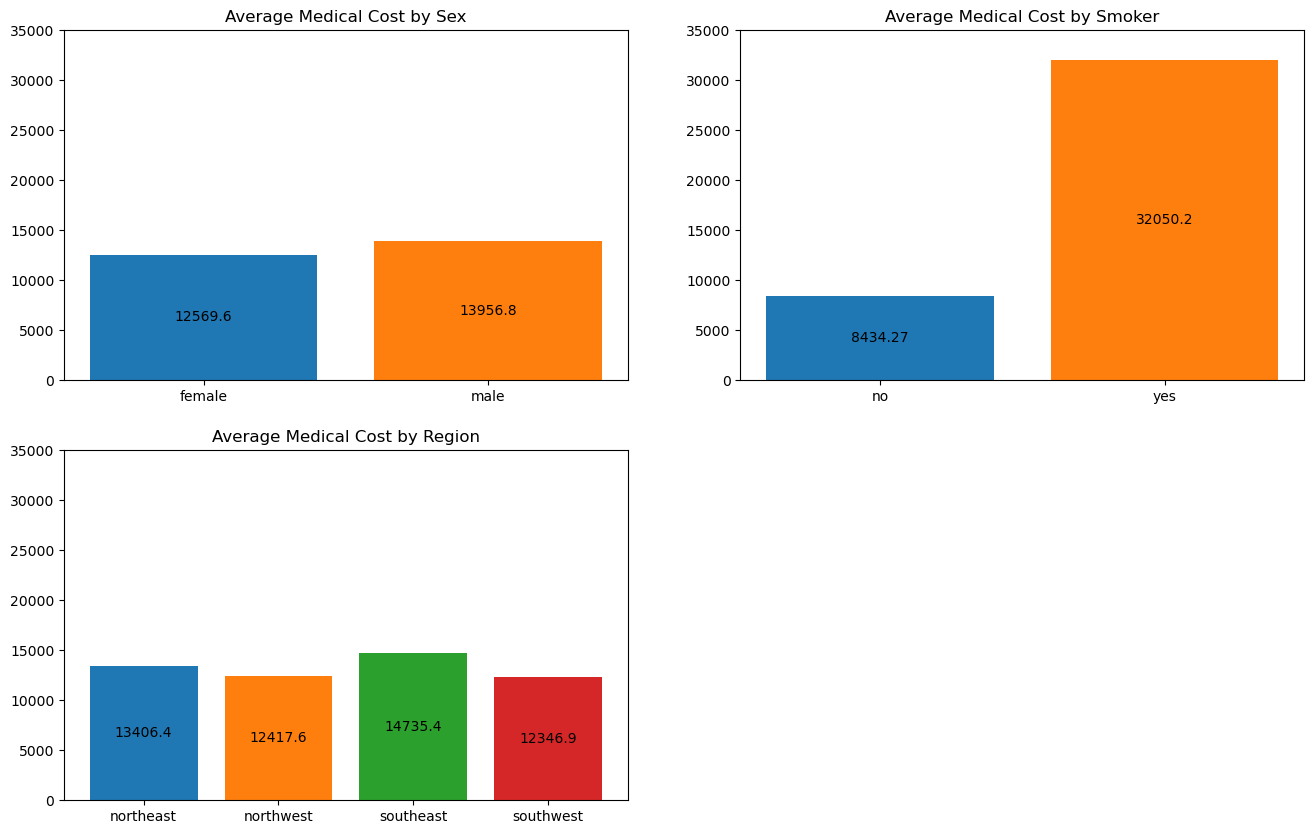

In [122]:
cat_cols=['sex','smoker','region']
plt.figure(figsize=(16,10))
for idx, col in enumerate(cat_cols):
    avg=df.groupby(col)['charges'].mean()
    ax=plt.subplot(2,2,idx+1)
    ax.bar(avg.index,avg, color=sns.color_palette('tab10'))
    ax.set_title(f'Average Medical Cost by {col.title()}')
    ax.set_ylim(0,35000)
    #add bar labels
    for c in ax.containers:
        ax.bar_label(c,label_type = 'center')
    
plt.show()

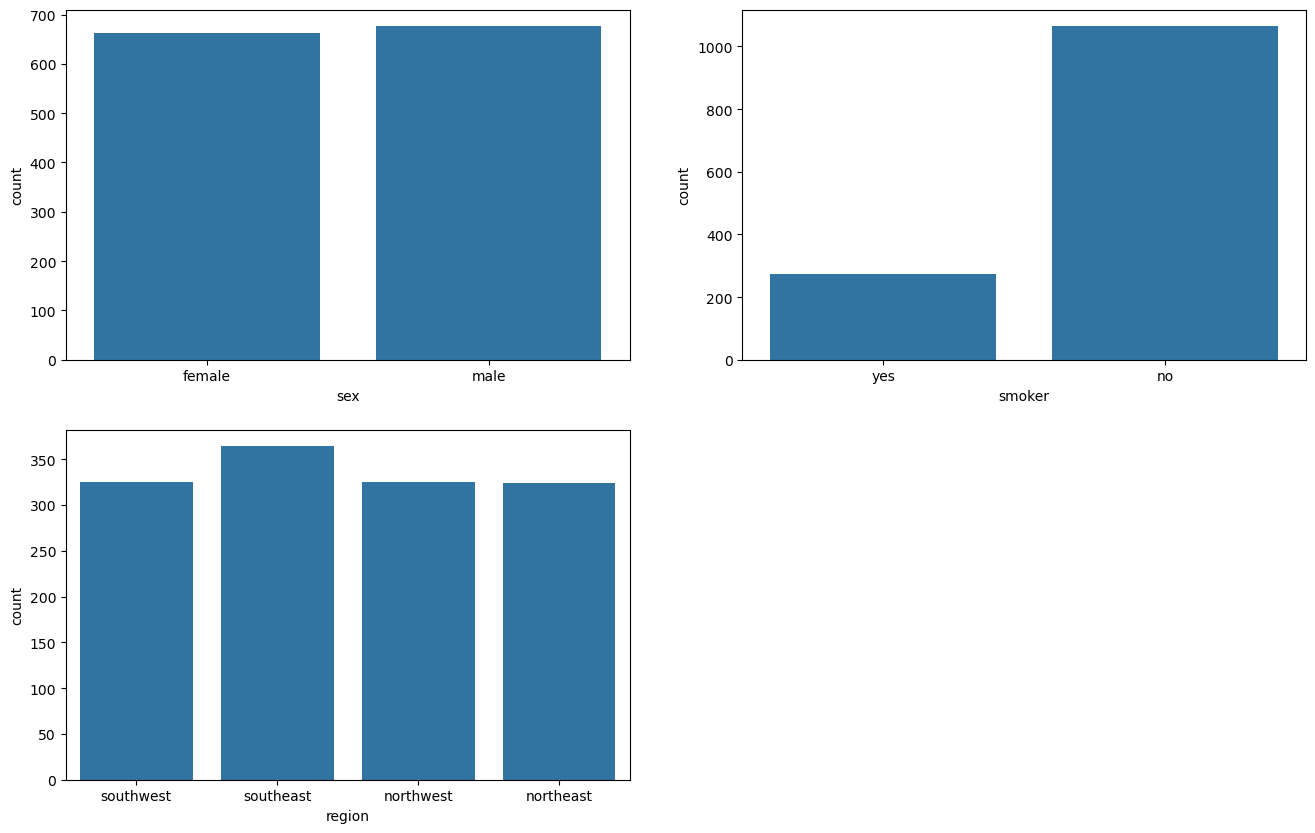

In [123]:
#plot countplot of the categorical columns

plt.figure(figsize=(16,10))
for idx, col in enumerate(cat_cols):
    ax=plt.subplot(2,2,idx+1)
    sns.countplot(x=df[col],ax=ax)
plt.show()

From the bar charts, there are some noticable summaries:
- The non-smokers are almost as three times as smokers.
- There is a significant difference in the average medical cost between smokers and non-smokers
- The average medical cost for males is slightly higher than that for females
- The average medical cost in the Southeast regions is slightly higher than other regions

let's plot the numerical data

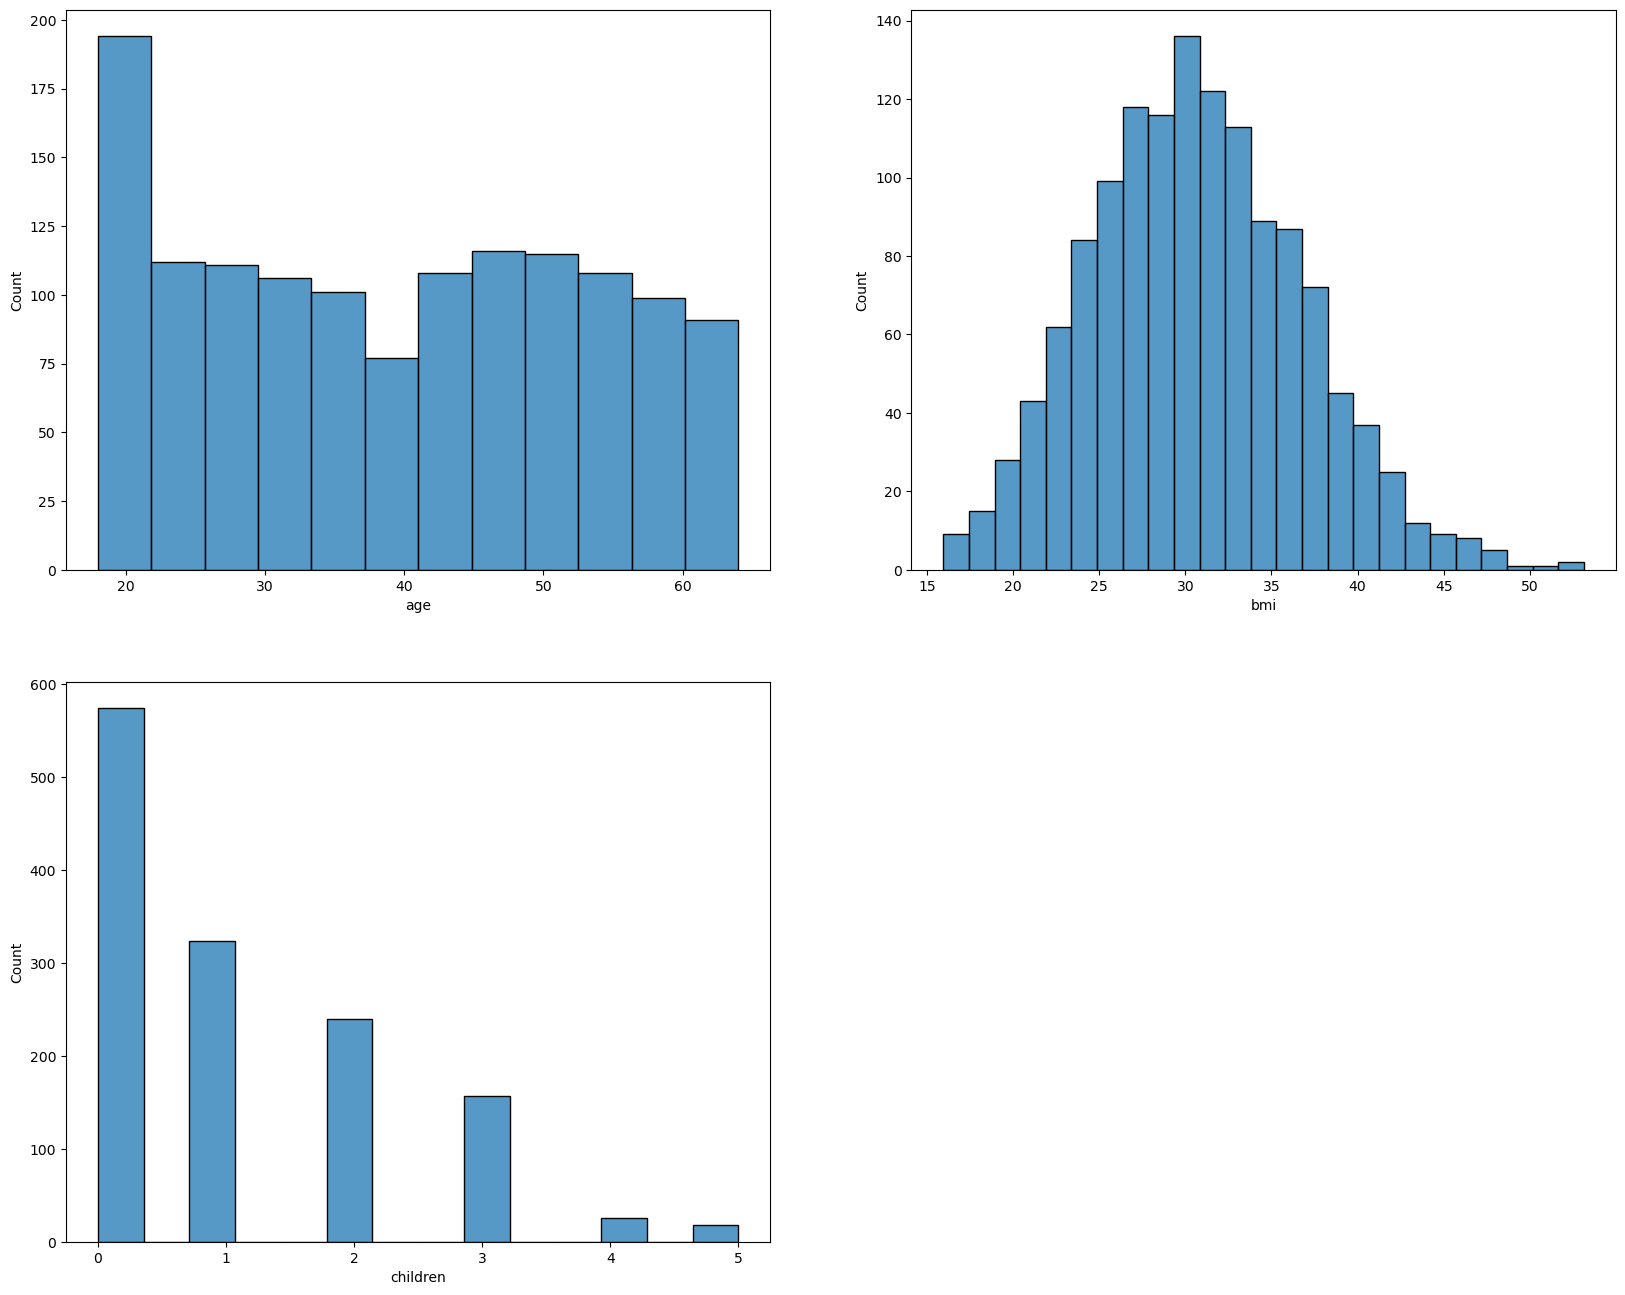

In [124]:
num_cols=['age','bmi','children']
plt.figure(figsize=(20,16))
for idx, col in enumerate(num_cols):
    ax=plt.subplot(2,2,idx+1)
    sns.histplot(x=df[col],ax=ax)
#cplt.show()

In [125]:
#check the skewness of the numerical data
for col in num_cols:
    print(f'{col} skewness is : {df[col].skew()}')

age skewness is : 0.05567251565299186
bmi skewness is : 0.2840471105987448
children skewness is : 0.9383804401702414


Overall, the columns are more or less right-skewed, but still in accepatable range.
Let's move on to transform datasets for machine learning.

## Feature Engineering

Since machine learning model can only take in numerical data, let's convert all categorical data to numerical type.

In [126]:
#check the unique values in the categorical columns
print(df['sex'].unique(),
df['smoker'].unique(),
df['region'].unique())

['female' 'male'] ['yes' 'no'] ['southwest' 'southeast' 'northwest' 'northeast']


In [127]:
# convert the columns of 'sex' and 'smoker' to numerical data
df['sex']=df['sex'].apply(lambda x: 1 if x=="male" else 0)
df['smoker']=df['smoker'].apply(lambda x: 1 if x=='yes' else 0)

In [128]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   int64  
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   int64  
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(4), object(1)
memory usage: 73.3+ KB


In [129]:
# let's convert 'region' column to the dummy variables.
df_fn=pd.get_dummies(df,dtype='int64')

In [130]:
df_fn.head()

,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,0,0,0,1
1,18,1,33.770,1,0,1725.55230,0,0,1,0
2,28,1,33.000,3,0,4449.46200,0,0,1,0
3,33,1,22.705,0,0,21984.47061,0,1,0,0
4,32,1,28.880,0,0,3866.85520,0,1,0,0


## Feature Selection

Let's check the correlations between variables

In [131]:
#checking the correlations between variables
abs(df_fn.corr()['charges']).sort_values(ascending=False)

charges             1.000000
smoker              0.787251
age                 0.299008
bmi                 0.198341
region_southeast    0.073982
children            0.067998
sex                 0.057292
region_southwest    0.043210
region_northwest    0.039905
region_northeast    0.006349
Name: charges, dtype: float64

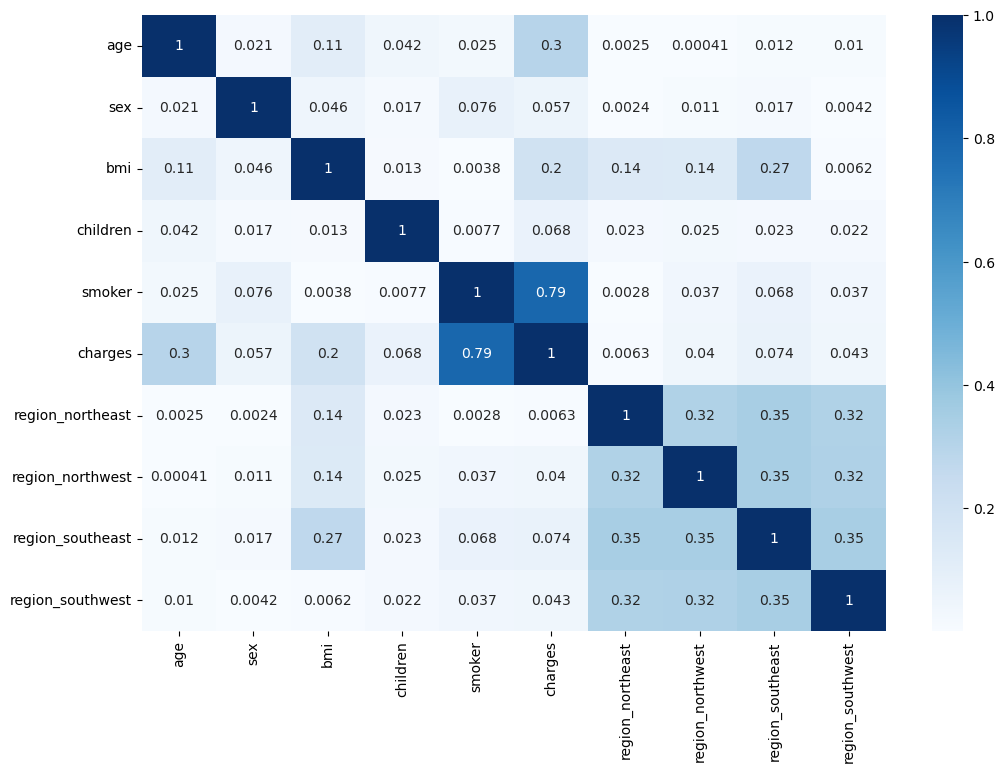

In [132]:
cor=abs(df_fn.corr())
plt.figure(figsize=(12,8))
sns.heatmap(cor,annot=True, cmap='Blues')
plt.show()

Based on the correlations, let's select the predictors with correlation coefficient greater than 0.1

In [133]:
# select 'smoker','age','bmi' as the predictors
prd_cols=abs(df_fn.corr()['charges']).sort_values(ascending=False)[1:4].index

In [134]:
prd_cols

Index(['smoker', 'age', 'bmi'], dtype='object')

## Build the Model(Original Scaled Dependent Variable)

In [135]:
X=df_fn[list(prd_cols)]


In [136]:
y=df_fn['charges']

In [137]:
#split the data as train(80%) and test(20%) sets
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=216)

In [138]:
lr=LinearRegression()
lr.fit(X_train,y_train)

LinearRegression()

## Check the model fit

In [139]:
#calculate the predictions
y_train_prediction=lr.predict(X_train)


In [140]:
#Calculate the residuals
rsd1=y_train-y_train_prediction

In [141]:
# Calculate the residual mean
rsd1.mean()

-5.167969894186358e-12

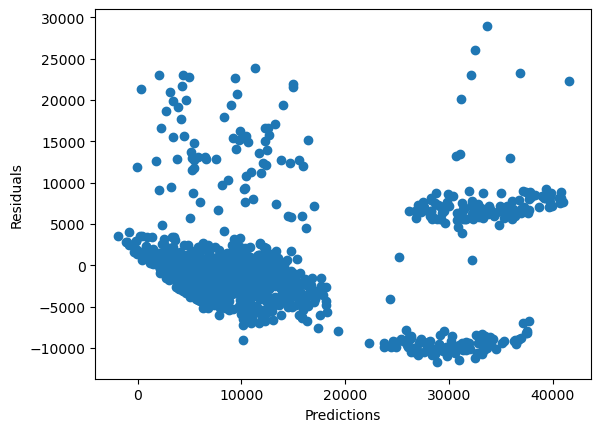

In [142]:
#plotting residual and fitted values 
plt.scatter(y_train_prediction,rsd1)
plt.xlabel('Predictions')
plt.ylabel('Residuals')
plt.show()

In [143]:
#Calculate the R-Squared
r2_score(y_train, y_train_prediction)

0.7409078461782312

In [144]:
#Calculate the mean squared error
mse_train=mean_squared_error(y_train, y_train_prediction)

In [145]:
mse_train

38247264.774518125

In [146]:
#Calculate the Root Mean Squared Error
rmse_train=mean_squared_error(y_train, y_train_prediction,squared=False)

C:\Users\Nicole\anaconda3\lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [147]:
rmse_train

6184.437304599192

Here is  a summary for the model fit on the training dataset:
- R-Squared is 0.74, indicating the model explains 74% of variations in the medical cost 
- Root mean squared error is 6184.43, which is relatively high considering the average medical cost is \$13270
- The mean of residuals is close to 0. However, as the predicted values become larger, the residuals increase. Th assumption  of heteroscedasticity seems being violated

## Interpretation of Coefficients

In [148]:
#Calculating the coefficients
coef=lr.coef_

In [149]:
coef

array([23763.78816853,   262.11489066,   324.82828408])

1. On average, the increase of medical cost is \$23763, if a patient is a smoker instead of a non-smoker, controlling for 'age' and 'bmi'
2. One unit increase in 'age' will increase medical cost \$262.11 on average, controlling for 'smoker' and 'bmi'
3. One unit increase in 'bmi' will increase medical cost  \$324.82 on average, controlling for 'smoker' and 'age'

## Model Evaluation and Cross Validation

In [150]:
#calculate the prediciton on the test dataset
y_prediction_test=lr.predict(X_test)

In [151]:
#calculate the root mean squared error on the test dataset
rmse_test=mean_squared_error(y_test, y_prediction_test, squared=False)

C:\Users\Nicole\anaconda3\lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [152]:
rmse_test

5662.573063963189

In [153]:
r2_test=r2_score(y_test,y_prediction_test)

In [154]:
r2_test

0.7745701525012659

The model performance is a slightly better on the test dataset. 
Let's perform a cross validation to examine the model performance

In [155]:
# perform 10 folds cross validation to calculate mean squared error
mse_cv=cross_val_score(lr,X,y,scoring='neg_mean_squared_error',cv=10)

In [156]:
mse_cv

array([-35331498.32656586, -38572462.050028  , -36979491.73179822,
       -38392777.30772665, -39263449.11397873, -27650777.28650513,
       -31884143.18464107, -48662902.91823519, -32937604.47859169,
       -42343202.52313934])

In [157]:
# The average value of root mean squared error  of 10 fold cross validation
np.sqrt(abs(mse_cv)).mean()

6082.520610956701

In [158]:
np.sqrt(abs(mse_cv))

array([5944.03047827, 6210.67323646, 6081.07652738, 6196.19054805,
       6266.05530729, 5258.4006396 , 5646.6045713 , 6975.88008199,
       5739.12924394, 6507.16547532])

The 10 fold cross validation confirms that the model perform is consistant with an average root mean squared error of 6082.52, which means the variance between prediction and observed values is 6082 on average.

## Summary

The test RMSE is about 5662.57, while the training RMSE is about 6184. The 10 fold cross validation has an average of 6082 RMSE. In general, the model performance is consistant. However, the examination of residuals revealed that the model violated the assumption of heteroscedasticity for linear regression. 
Given that the average of medical cost is \$13270, the average predicting error of 6082 is quite large. The model's prediction is not very accurate.

We might improve the model by employing the non-paramatric methods like decision three and random forest.